# Getting started with Megamicros objects
® *Copyright Bimea 2024-2025*

The `Megamicros` class is the base class for all *Megamicros* usb antennas. 
This Notebook shows how you can use the `Megamicros` interface provided you have a *Megamicros* device connected on your USB port.

Beware that you need to have `libusb` installed, both the python interface and the C libusb.1.0.26 library

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from megamicros.log import log
from megamicros.core.mu import Megamicros

# set log level to INFO to get more information (available levels are DEBUG, INFO, WARNING, ERROR, FATAL)
log.setLevel( "INFO" ) 

## Declare your antenna object

The ``Megamicros`` constructor needs no argument. The device is detected and the class device parameters are populated.

In [2]:
antenna = Megamicros()

2025-10-25 20:39:52,247 [INFO]:  .Connecting to USB device fe27:ac03 ...
2025-10-25 20:39:52,250 [INFO]:  .Claimed interface 0 on USB device fe27:ac03
2025-10-25 20:39:52,251 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-25 20:39:52,251 [INFO]:  .Connected on USB device fe27:ac03
2025-10-25 20:39:52,251 [INFO]:  .Performing selftest using bulk read method...
2025-10-25 20:39:52,252 [INFO]:  .Claimed interface 0 on USB device fe27:ac03
2025-10-25 20:39:52,617 [INFO]:  .Selftest completed successfully
2025-10-25 20:39:52,620 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-25 20:39:52,623 [INFO]:  .Autotest results:
2025-10-25 20:39:52,624 [INFO]:   > equivalent recording time is: 0.1 seconds
2025-10-25 20:39:52,625 [INFO]:   > Received 599760 data bytes: 4410 samples on 34 channels
2025-10-25 20:39:52,626 [INFO]:   > detected 8 active MEMs: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-25 20:39:52,627 [INFO]:   > detected no active analogs
2025-10-25 20:39:52,628 [INFO

availables mems =  [0, 1, 2, 3, 4, 5, 6, 7]


Lets know some properties of the connected antenna:

In [3]:
print( "Available MEMS: ", antenna.available_mems )
print( "Available Analogs: ", antenna.available_analogs )

Available MEMS:  [0, 1, 2, 3, 4, 5, 6, 7]
Available Analogs:  []


Try 1s of acquisition on all available MEMs

In [4]:
antenna.setActiveMems( antenna.available_mems )
antenna.setActiveAnalogs( antenna.available_analogs )
antenna.setDuration( 1 )
antenna.run()
antenna.wait()

2025-10-25 20:39:59,646 [INFO]:  .Starting run execution on Megamicros device...
2025-10-25 20:39:59,648 [INFO]:   > Perform 1s run loop
2025-10-25 20:39:59,648 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-25 20:39:59,649 [INFO]:   > FPGA clockdiv value: 9
2025-10-25 20:39:59,649 [INFO]:   > 8 activated microphones
2025-10-25 20:39:59,650 [INFO]:   > Activated microphones: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-25 20:39:59,651 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-25 20:39:59,652 [INFO]:   > 0 activated analogic channels
2025-10-25 20:39:59,653 [INFO]:   > Activated analogic channels: []
2025-10-25 20:39:59,653 [INFO]:   > Analogics sensibility: 0.33
2025-10-25 20:39:59,654 [INFO]:   > Whether counter is activated: YES
2025-10-25 20:39:59,654 [INFO]:   > Whether status is activated: NO
2025-10-25 20:39:59,654 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-25 20:39:59,655 [INFO]:   > Total channels number is 9
2025-10-25 20:39:59,655 [INFO]:   > Datatype: int32

Getting data can be done by iterate through the `antenna` object provided the antenna had already received all the data:

In [5]:
# Print frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

# Retrieve data from the queue
for data in antenna:
    print( f"data={data}" )

queue content : 49 frames
data=[[ 10526  10527  10528 ...  11547  11548  11549]
 [ -3280  -3966  -5430 ... -12116  -2326 -10386]
 [ -1582   2482   2712 ... -21080  11428 -26826]
 ...
 [-10812 -13592 -12018 ...  -5982 -16550 -16566]
 [ -6710  -3444  -3930 ...  -4184 -19662  -2886]
 [ -3186  -1700  -4124 ... -19218  11002 -21968]]
data=[[ 11550  11551  11552 ...  12571  12572  12573]
 [ -2294 -10166  -6582 ...    842    948   1046]
 [ 13692 -27912  11784 ...   -240   1114   4660]
 ...
 [ -7810 -21326   3344 ...  -6548  -4214  -3424]
 [-22584      2 -19934 ...  -3936  -1220  -2222]
 [ 14500 -24198  11478 ...  -1446  -3146  -2154]]
data=[[ 12574  12575  12576 ...  13595  13596  13597]
 [  1224    514    624 ...   5064  -4540   5880]
 [  5178   6222   3096 ... -20168  19054 -13892]
 ...
 [  -798  -1260  -2242 ... -12304   8002 -12224]
 [  2952   3938   2724 ...   4590  -7216   6232]
 [  -896   -798     90 ... -11768   8918  -7914]]
data=[[ 13598  13599  13600 ...  14619  14620  14621]
 [ -4

Once the frames have been retrieved, the queue is empty:

In [6]:
# Print frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

queue content : 0 frames


You can force some MEMs to be activated while they are not available. 
Corresponding channels will stay at 0. However you cannot activate MEMS over the device you are connected to (MEMS 128 on a 32 system for example).

In [7]:
antenna.selftest()
available_mems = antenna.available_mems
print( "Available MEMS are: ", antenna.available_mems )

# Activate a MEMS that is not available (supposing 18 is not available)
antenna.setActiveMems( [18] )

antenna.run()
antenna.wait()

# Print frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

# Retrieve data from the queue
for data in antenna:
    print( f"data={data}" )

2025-10-25 20:40:11,368 [INFO]:  .Performing selftest using bulk read method...
2025-10-25 20:40:11,370 [INFO]:  .Claimed interface 0 on USB device fe27:ac03
2025-10-25 20:40:11,747 [INFO]:  .Selftest completed successfully
2025-10-25 20:40:11,748 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-25 20:40:11,749 [INFO]:  .Autotest results:
2025-10-25 20:40:11,750 [INFO]:   > equivalent recording time is: 0.1 seconds
2025-10-25 20:40:11,750 [INFO]:   > Received 680000 data bytes: 5000 samples on 34 channels
2025-10-25 20:40:11,751 [INFO]:   > detected 8 active MEMs: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-25 20:40:11,751 [INFO]:   > detected no active analogs
2025-10-25 20:40:11,751 [INFO]:   > detected counter channel with values from 10663 to 15662
2025-10-25 20:40:11,752 [INFO]:   > estimated data lost: 0 samples
2025-10-25 20:40:11,752 [INFO]:   > detected status channel with values 0 <-> 16
2025-10-25 20:40:11,753 [INFO]:  .Selftest endded successfully
2025-10-25 20:40:11,754

availables mems =  [0, 1, 2, 3, 4, 5, 6, 7]
Available MEMS are:  [0, 1, 2, 3, 4, 5, 6, 7]


2025-10-25 20:40:12,039 [INFO]:  .Init asynchronous bulk transfer...
2025-10-25 20:40:12,040 [INFO]:  .Transfer thread execution started
2025-10-25 20:40:13,043 [INFO]:  .Thread timer ended: stop the bulk transfer...
2025-10-25 20:40:13,063 [INFO]:  .Quitting transfer loop due to end of process request...
2025-10-25 20:40:13,065 [INFO]:  .Released interface 0 on USB device fe27:ac03
2025-10-25 20:40:13,066 [INFO]:  .Megamicros acquisition process successfully ended


queue content : 50 frames
data=[[10351 10352 10353 ... 11372 11373 11374]
 [    0     0     0 ...     0     0     0]]
data=[[11375 11376 11377 ... 12396 12397 12398]
 [    0     0     0 ...     0     0     0]]
data=[[12399 12400 12401 ... 13420 13421 13422]
 [    0     0     0 ...     0     0     0]]
data=[[13423 13424 13425 ... 14444 14445 14446]
 [    0     0     0 ...     0     0     0]]
data=[[14447 14448 14449 ... 15468 15469 15470]
 [    0     0     0 ...     0     0     0]]
data=[[15471 15472 15473 ... 16492 16493 16494]
 [    0     0     0 ...     0     0     0]]
data=[[16495 16496 16497 ... 17516 17517 17518]
 [    0     0     0 ...     0     0     0]]
data=[[17519 17520 17521 ... 18540 18541 18542]
 [    0     0     0 ...     0     0     0]]
data=[[18543 18544 18545 ... 19564 19565 19566]
 [    0     0     0 ...     0     0     0]]
data=[[19567 19568 19569 ... 20588 20589 20590]
 [    0     0     0 ...     0     0     0]]
data=[[20591 20592 20593 ... 21612 21613 21614]
 [    

Settings can be passed to the run() method as well:

In [8]:
antenna.run(
    duration=1,                             # acquisition time in seconds 
    mems = antenna.available_mems,          # activate all available MEMs
    counter = False,                        # do not get counter channel
    status = False,                         # do not get status channel
    datatype = 'int32',                     # set datatype to ìnt32 (default)
    sampling_frequency=50000                # set sampling frequency to 50kHz
)

antenna.wait()

2025-10-25 20:41:07,512 [INFO]:  .Starting run execution on Megamicros device...
2025-10-25 20:41:07,514 [INFO]:   > Perform 1s run loop
2025-10-25 20:41:07,515 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-25 20:41:07,515 [INFO]:   > FPGA clockdiv value: 9
2025-10-25 20:41:07,516 [INFO]:   > 8 activated microphones
2025-10-25 20:41:07,516 [INFO]:   > Activated microphones: [0, 1, 2, 3, 4, 5, 6, 7]
2025-10-25 20:41:07,517 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-25 20:41:07,518 [INFO]:   > 0 activated analogic channels
2025-10-25 20:41:07,519 [INFO]:   > Activated analogic channels: []
2025-10-25 20:41:07,519 [INFO]:   > Analogics sensibility: 0.33
2025-10-25 20:41:07,520 [INFO]:   > Whether counter is activated: NO
2025-10-25 20:41:07,520 [INFO]:   > Whether status is activated: NO
2025-10-25 20:41:07,521 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-25 20:41:07,521 [INFO]:   > Total channels number is 8
2025-10-25 20:41:07,521 [INFO]:   > Datatype: int32


In [9]:
# Only set MEMS 0 and 10. All previous args remain the same:
antenna.run( 
    mems = [0, 10],
)

antenna.wait()

2025-10-25 20:41:11,731 [INFO]:  .Starting run execution on Megamicros device...
2025-10-25 20:41:11,732 [INFO]:   > Perform 1s run loop
2025-10-25 20:41:11,733 [INFO]:   > Sampling frequency: 50000 Hz
2025-10-25 20:41:11,734 [INFO]:   > FPGA clockdiv value: 9
2025-10-25 20:41:11,735 [INFO]:   > 2 activated microphones
2025-10-25 20:41:11,736 [INFO]:   > Activated microphones: [0, 10]
2025-10-25 20:41:11,736 [INFO]:   > MEMs sensibility: 3.54e-06
2025-10-25 20:41:11,737 [INFO]:   > 0 activated analogic channels
2025-10-25 20:41:11,737 [INFO]:   > Activated analogic channels: []
2025-10-25 20:41:11,738 [INFO]:   > Analogics sensibility: 0.33
2025-10-25 20:41:11,738 [INFO]:   > Whether counter is activated: NO
2025-10-25 20:41:11,739 [INFO]:   > Whether status is activated: NO
2025-10-25 20:41:11,739 [INFO]:   > Time activation (MEMS powering delay): 200 ms
2025-10-25 20:41:11,740 [INFO]:   > Total channels number is 2
2025-10-25 20:41:11,740 [INFO]:   > Datatype: int32
2025-10-25 20:41:

The previous method suggests that real time is not possible.
Actually, you can perform real time acqusition if you iterate before calling the `wait` method, just after the `run` call. 
The important point is that the `run()` call is a non-blocking. As such it implies that the `wait()` method is mandatory and must not be forgotten: 

In [11]:
log.setLevel( "WARNING" ) 

antenna.run( 
    duration=1,       # acquisition time in seconds
    mems=[0, 1],      # activate only MEMs 0 and 1
    counter=True,     # get counter channel 
)

# Get only the counter (first channel)
for data in antenna:
    print( f"Counter value: {data[0][0]}" )

antenna.wait()

# No more frames stored in the queue
print(f"queue content : {antenna.queue_content} frames")

Counter value: 10526
Counter value: 11550
Counter value: 12574
Counter value: 13598
Counter value: 14622
Counter value: 15646
Counter value: 16670
Counter value: 17694
Counter value: 18718
Counter value: 19742
Counter value: 20766
Counter value: 21790
Counter value: 22814
Counter value: 23838
Counter value: 24862
Counter value: 25886
Counter value: 26910
Counter value: 27934
Counter value: 28958
Counter value: 29982
Counter value: 31006
Counter value: 32030
Counter value: 33054
Counter value: 34078
Counter value: 35102
Counter value: 36126
Counter value: 37150
Counter value: 38174
Counter value: 39198
Counter value: 40222
Counter value: 41246
Counter value: 42270
Counter value: 43294
Counter value: 44318
Counter value: 45342
Counter value: 46366
Counter value: 47390
Counter value: 48414
Counter value: 49438
Counter value: 50462
Counter value: 51486
Counter value: 52510
Counter value: 53534
Counter value: 54558
Counter value: 55582
Counter value: 56606
Counter value: 57630
Counter value

Let us measure the acquisition time: 

In [12]:
start_time = time.time()
antenna.run( 
    duration=1,       # acquisition time in seconds
    mems=[0, 1],      # activate only MEMs 0 and 1
    counter=True,     # get counter channel 
)
# Get only the counter (first channel)
counter = []
for data in antenna:
    counter.append(int(data[0][0]))
antenna.wait()
end_time = time.time()

print(f"Acquisition time: {end_time - start_time} seconds")

Acquisition time: 3.292469024658203 seconds


Note that the elapsed time reaches 3.2 seconds, whereas the requested acquisition time was 1 second.

The method, as reported above, includes, in addition to the acquisition time (1s):
* The MEMs initialization delay (MEMs powering), default is 200 millisecond
* The timeout delay to leave the queue (2 seconds)
As a consequence, the total elapsed is 3.2 secondes.

In the next example we decide to supress the MEMS powering delay by setting to 0 the `time_activation` setting:


Acquisition time: 3.0869791507720947 seconds


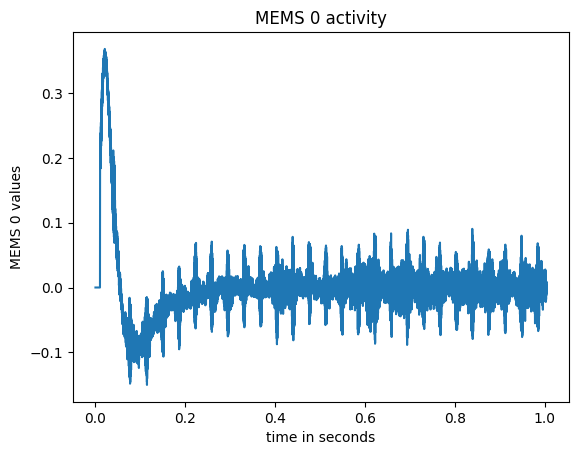

Counter values: [  264   265   266 ... 50437 50438 50439]


In [14]:
log.setLevel( "WARNING" ) 
import time
start_time = time.time()

antenna.run( 
    duration=1,       # acquisition time in seconds
    mems=[0, 1],      # activate only MEMs 0 and 1
    counter=True,     # get counter channel
    time_activation=0 # no delay for MEMs powering
)

# Get only the counter (first channel) and the MEMS 0 data (second channel)
counter = np.array( [] )
mems_0 = np.array( [] )
for data in antenna:
    counter = np.append(counter.astype(int), data[0][:])    # Counter data
    mems_0 = np.append(mems_0.astype(float), data[1][:])      # MEMS 0 data
antenna.wait()
end_time = time.time()

print(f"Acquisition time: {end_time - start_time} seconds")

t = np.array( range( len(mems_0) ) )/antenna.sampling_frequency
signal = mems_0 * antenna.mems_sensibility

# Plot mems_0:
plt.figure()
plt.plot( t, signal )
plt.title('MEMS 0 activity')
plt.xlabel('time in seconds')
plt.ylabel('MEMS 0 values')
plt.show()

print( f"Counter values: {counter}" )

You can see during the first 200ms start of the signal a transitory state which correspond to the MEMS powering. 
The values of the counter variable are lower because we are very close to the start of acquisition.

## Analog channels

If you have a Megamicros system that embed analog inputs, all you have to do is to declare them if you want to get those signals:


In [15]:
print( f"Available analog channels = {antenna.available_analogs}" )

antenna.run( 
    duration=1, 
    mems = [0, 1],
    analogs = [0, 1],
    counter=False, 
    status=False,
    datatype = 'int32',
    sampling_frequency=50000
)

# Wait until the thread terminates
antenna.wait()

Available analog channels = []
